In [2]:
import pandas as pd
import numpy as np


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\shanmukha\Calibo\data Sets\Phase_2_dataSets\Supervised_Learning_Messy_Customer_Churn.csv")

In [5]:
df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [6]:
df.shape

(184, 13)

In [7]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    object 
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    object 
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    object 
 9   Payment_Method         184 non-null    object 
 10  Region                 184 non-null    object 
 11  Plan_Type              184 non-null    object 
 12  Churn                  184 non-null    object 
dtypes: float64(6), object(7)
memory usage: 18.8+ KB


In [11]:
df.describe(include='all')

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
count,184,176.000000,173,177.000000,178.000000,179.000000,178.000000,178.000000,184,184,184,184,184
unique,180,NaN,156,NaN,NaN,NaN,NaN,NaN,8,9,8,6,2
top,CUST-1043,NaN,76600.0,NaN,NaN,NaN,NaN,NaN,Monthly,Bank Transfer,South,Standard,Yes
freq,2,NaN,4,NaN,NaN,NaN,NaN,NaN,104,48,50,93,97
mean,NaN,36.164773,NaN,39.395480,80.205899,3.217877,17.806180,5.803371,NaN,NaN,NaN,NaN,NaN
std,NaN,12.865951,NaN,21.545185,74.179370,2.577455,9.245516,2.947869,NaN,NaN,NaN,NaN,NaN
min,NaN,-5.000000,NaN,1.000000,0.000000,0.000000,-10.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,29.000000,NaN,25.000000,57.885000,2.000000,11.600000,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,36.000000,NaN,38.000000,73.565000,3.000000,18.200000,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,41.000000,NaN,55.000000,90.280000,4.000000,24.200000,8.000000,NaN,NaN,NaN,NaN,NaN


In [12]:
df.nunique()

Customer_ID              180
Age                       44
Annual_Income            156
Tenure_Months             66
Monthly_Charges          169
Support_Calls_Last_3M      9
Data_Usage_GB            132
Satisfaction_Score        11
Contract_Type              8
Payment_Method             9
Region                     8
Plan_Type                  6
Churn                      2
dtype: int64

In [13]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.sort_values("Customer_ID")

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
132,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
154,CUST-1008,44.0,43400.0,60.0,95.26,2.0,26.9,1.0,Monthly,Debit Card,South,Basic,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
119,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
46,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
71,CUST-1110,35.0,29800.0,72.0,115.28,2.0,18.9,5.0,1 Year,Bank Transfer,West,Premium,Yes
169,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No
176,CUST-1152,39.0,76600.0,25.0,90.28,4.0,8.4,8.0,Monthly,Bank Transfer,West,Premium,No


In [14]:
df = df.drop_duplicates() #removing duplicate rows

In [15]:
df["Customer_ID"].nunique()

180

In [16]:
missing_summary = pd.DataFrame({   #identifyig missing values
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Age,8,4.44
Annual_Income,11,6.11
Tenure_Months,7,3.89
Monthly_Charges,6,3.33
Support_Calls_Last_3M,5,2.78
Data_Usage_GB,6,3.33
Satisfaction_Score,6,3.33


In [17]:
df.isnull().sum().sum() #total number of missing values in the dataset

np.int64(49)

In [18]:
df.isnull().sum().sum()/len(df) * 100 #missing values percentage in the dataset

np.float64(27.22222222222222)

In [19]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].unique())


--- Customer_ID ---
['CUST-1020' 'CUST-1043' 'CUST-1157' 'CUST-1112' 'CUST-1149' 'CUST-1016'
 'CUST-1025' 'CUST-1069' 'CUST-1118' 'CUST-1099' 'CUST-1098' 'CUST-1163'
 'CUST-1070' 'CUST-1175' 'CUST-1046' 'CUST-1017' 'CUST-1052' 'CUST-1036'
 'CUST-1083' 'CUST-1057' 'CUST-1165' 'CUST-1125' 'CUST-1147' 'CUST-1031'
 'CUST-1010' 'CUST-1127' 'CUST-1061' 'CUST-1019' 'CUST-1170' 'CUST-1114'
 'CUST-1076' 'CUST-1056' 'CUST-1120' 'CUST-1136' 'CUST-1067' 'CUST-1030'
 'CUST-1176' 'CUST-1066' 'CUST-1068' 'CUST-1032' 'CUST-1013' 'CUST-1042'
 'CUST-1137' 'CUST-1091' 'CUST-1148' 'CUST-1105' 'CUST-1110' 'CUST-1039'
 'CUST-1121' 'CUST-1097' 'CUST-1077' 'CUST-1160' 'CUST-1003' 'CUST-1134'
 'CUST-1047' 'CUST-1173' 'CUST-1156' 'CUST-1086' 'CUST-1151' 'CUST-1027'
 'CUST-1159' 'CUST-1177' 'CUST-1116' 'CUST-1079' 'CUST-1037' 'CUST-1129'
 'CUST-1023' 'CUST-1109' 'CUST-1123' 'CUST-1115' 'CUST-1012' 'CUST-1146'
 'CUST-1007' 'CUST-1028' 'CUST-1094' 'CUST-1005' 'CUST-1033' 'CUST-1101'
 'CUST-1144' 'CUST-1102' 'CUST

In [20]:
income_numeric = pd.to_numeric(df["Annual_Income"], errors="coerce")


invalid_values = df[
    (df["Age"] < 18) |
    (df["Age"] > 122) |
    (income_numeric <= 0) |
    (df["Data_Usage_GB"] < 0)
].copy()

invalid_values

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
6,CUST-1025,31.0,88000.0,37.0,88.42,4.0,-2.1,9.0,1 Year,Debit Card,South,Standard,No
45,CUST-1105,34.0,35800.0,60.0,118.63,3.0,-0.8,7.0,2 Year,UPI,East,Standard,No
63,CUST-1079,NaN,53100.0,29.0,83.71,3.0,-1.6,5.0,Monthly,UPI,North,Basic,Yes
77,CUST-1033,36.0,57800.0,72.0,50.61,3.0,-1.1,1.0,Monthly,Credit Card,North,Standard,Yes
95,CUST-1143,20.0,-11500.0,2.0,57.34,NaN,19.4,2.0,1 Year,Credit Card,West,Standard,No
100,CUST-1080,16.0,NaN,8.0,84.70,1.0,30.5,5.0,Monthly,Credit Card,West,Basic,Yes
112,CUST-1062,34.0,-12000.0,29.0,60.69,4.0,18.9,4.0,Monthly,UPI,East,Basic,Yes
120,CUST-1124,22.0,50100.0,57.0,93.56,3.0,-0.3,9.0,Monthly,UPI,South,Standard,No
127,CUST-1004,145.0,55500.0,35.0,120.65,2.0,14.3,6.0,1 Year,Credit Card,East,Premium,No
133,CUST-1111,17.0,31700.0,31.0,62.54,3.0,30.1,10.0,Monthly,Credit Card,South,Standard,No


In [21]:
print("Invalid age:", ((df["Age"] < 18) | (df["Age"] > 122)).sum())
print("Negative income:", (income_numeric < 0).sum())
print("Negative data usage:", (df["Data_Usage_GB"] < 0).sum())
print("Total rows shown:", invalid_values.shape[0])

Invalid age: 7
Negative income: 2
Negative data usage: 7
Total rows shown: 16


In [22]:
# Convert Annual_Income to numeric
df["Annual_Income"] = pd.to_numeric(df["Annual_Income"], errors="coerce")

# Replace confirmed invalid values with NaN
df.loc[(df["Age"] < 18) | (df["Age"] > 122), "Age"] = np.nan
df.loc[df["Annual_Income"] < 0, "Annual_Income"] = np.nan
df.loc[df["Data_Usage_GB"] < 0, "Data_Usage_GB"] = np.nan

In [23]:
# Categorical columns only exceptCustomer_ID
category_cols = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type",
    "Churn"
]

#  dealing with case-insensitive and white spaces
for col in category_cols:
    df[col] = df[col].str.strip().str.casefold()

# Convert placeholder / unknown category values to missing
df[category_cols] = df[category_cols].replace({
    "?": np.nan,
    "na": np.nan,
    "n/a": np.nan,
    "": np.nan,
    "unknown": np.nan
})

# Format simple categories
df["Region"] = df["Region"].str.capitalize()
df["Plan_Type"] = df["Plan_Type"].str.capitalize()
df["Churn"] = df["Churn"].str.capitalize()

# Format payment method and correct UPI
df["Payment_Method"] = df["Payment_Method"].str.title()
df["Payment_Method"] = df["Payment_Method"].replace({"Upi": "UPI"})

# Standardize contract labels
df["Contract_Type"] = (
    df["Contract_Type"]
    .str.replace("-", " ", regex=False)
    .str.title()
)

In [24]:
df.isnull().sum().sum()

np.int64(70)

In [25]:
df[
    (df["Annual_Income"] > 500000) |
    (df["Tenure_Months"] > 120) |
    (df["Monthly_Charges"] > 300) |
    (df["Support_Calls_Last_3M"] > 15) |
    (df["Satisfaction_Score"] > 10)
]

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
35,CUST-1030,33.0,83900.0,42.0,80.50,30.0,19.0,3.0,2 Year,Credit Card,North,Standard,Yes
40,CUST-1013,38.0,76600.0,150.0,64.92,3.0,20.8,9.0,1 Year,UPI,East,Standard,No
96,CUST-1026,37.0,9999999.0,5.0,91.79,4.0,6.4,9.0,1 Year,Bank Transfer,East,Premium,No
157,CUST-1089,31.0,54600.0,36.0,999.00,4.0,NaN,10.0,1 Year,Credit Card,West,Standard,Yes
166,CUST-1053,29.0,53900.0,51.0,55.06,2.0,24.5,15.0,1 Year,Bank Transfer,South,Basic,Yes


In [26]:
df.loc[df["Annual_Income"] > 500000, "Annual_Income"] = np.nan
df.loc[df["Monthly_Charges"] > 300, "Monthly_Charges"] = np.nan
df.loc[df["Satisfaction_Score"] > 10, "Satisfaction_Score"] = np.nan

In [27]:
print("Shape:", df.shape)
print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print(f"total missing values:{df.isnull().sum().sum()}")

print("\nData types:")
print(df.dtypes)

Shape: (180, 13)

Duplicate rows: 0

Missing values:
Customer_ID               0
Age                      15
Annual_Income            15
Tenure_Months             7
Monthly_Charges           7
Support_Calls_Last_3M     5
Data_Usage_GB            13
Satisfaction_Score        7
Contract_Type             1
Payment_Method            2
Region                    1
Plan_Type                 0
Churn                     0
dtype: int64
total missing values:73

Data types:
Customer_ID               object
Age                      float64
Annual_Income            float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

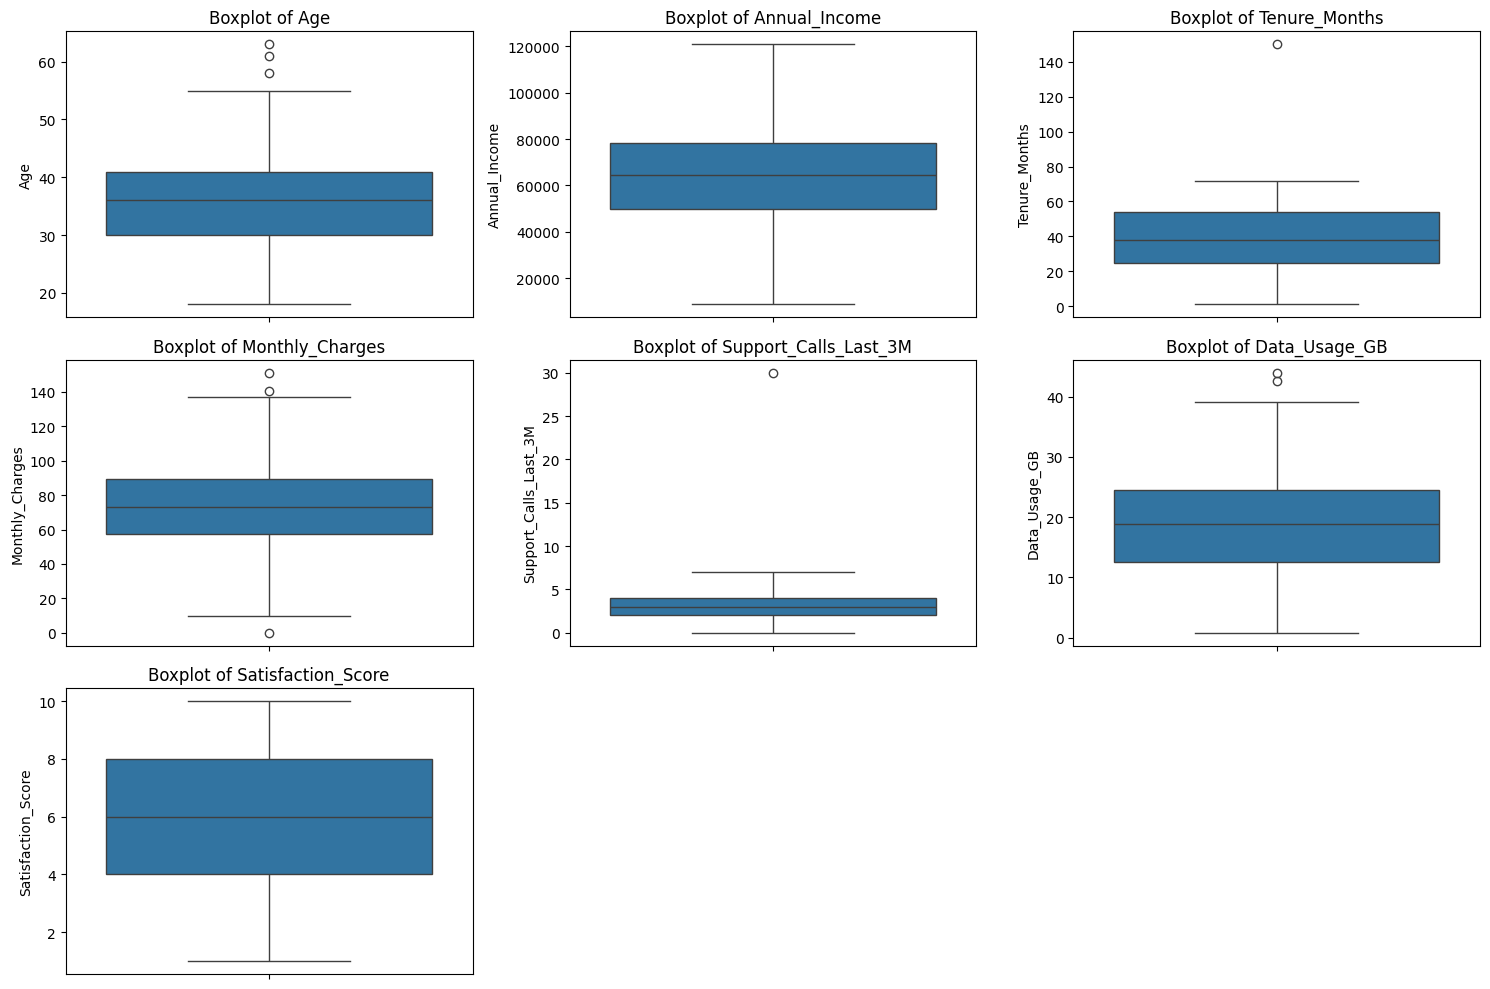

In [32]:
#checking outliers

numeric_cols = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

## Outlier Decision

Boxplots identified unusual but potentially valid observations, including very low
or high tenure, zero monthly charges, and high support-call counts. These values
were retained because they may represent genuine customer behaviour and can be
important churn signals. Only clearly impossible or implausible values were
converted to missing values.

In [33]:
# Churn rate by contract type
contract_churn_rate = (
    df.groupby("Contract_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(contract_churn_rate.round(2))

Contract_Type
Monthly    63.11
1 Year     46.15
2 Year     20.83
Name: Churn, dtype: float64


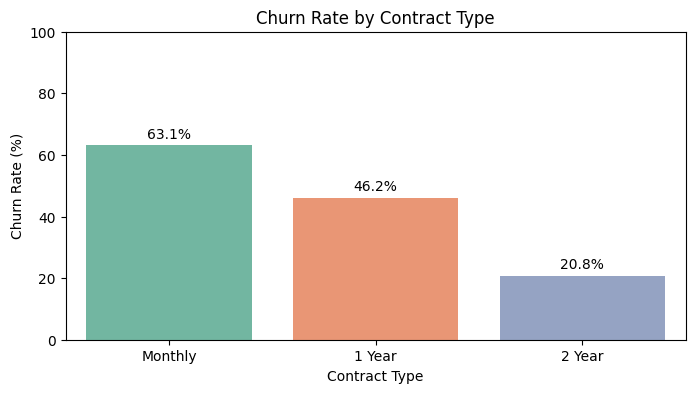

In [34]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values,
    hue=contract_churn_rate.index,   # makes colours different
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.show()

In [35]:
satisfaction_churn_rate = (
    df.groupby("Satisfaction_Score")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_index()
)

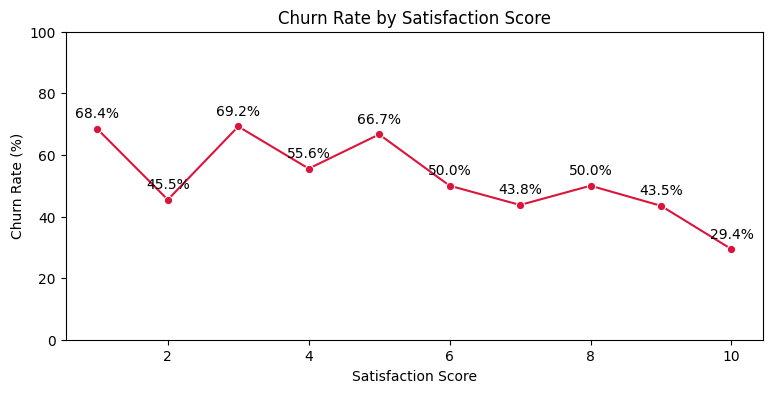

In [36]:
plt.figure(figsize=(9, 4))

ax = sns.lineplot(
    x=satisfaction_churn_rate.index,
    y=satisfaction_churn_rate.values,
    marker="o",
    color="crimson"
)

for x, y in zip(satisfaction_churn_rate.index, satisfaction_churn_rate.values):
    ax.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.show()

In [37]:
support_churn_rate = (
    df.groupby("Support_Calls_Last_3M")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_index()
)

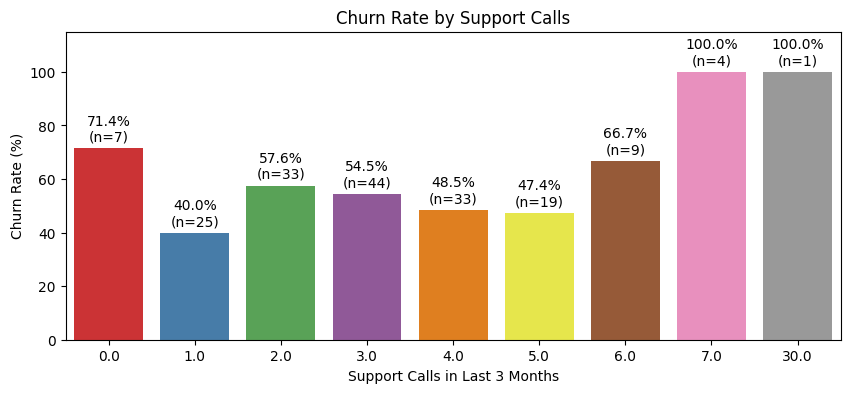

In [38]:
support_summary = df.groupby("Support_Calls_Last_3M").agg(
    Customer_Count=("Churn", "size"),
    Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(10, 4))

ab = sns.barplot(
    x=support_summary.index,
    y=support_summary["Churn_Rate"],
    hue=support_summary.index,
    palette="Set1",
    legend=False
)

plt.title("Churn Rate by Support Calls")
plt.xlabel("Support Calls in Last 3 Months")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 115)

for bar, count, rate in zip(
    ab.patches,
    support_summary["Customer_Count"],
    support_summary["Churn_Rate"]
):
    ab.annotate(
        f"{rate:.1f}%\n(n={count})",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.show()

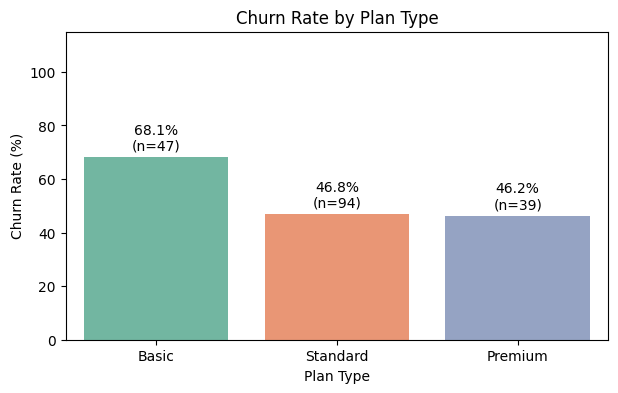

In [39]:
plan_summary = df.groupby("Plan_Type").agg(
    Customer_Count=("Churn", "size"),
    Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
).sort_values("Churn_Rate", ascending=False)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x=plan_summary.index,
    y=plan_summary["Churn_Rate"],
    hue=plan_summary.index,
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 115)

for bar, count, rate in zip(
    ax.patches,
    plan_summary["Customer_Count"],
    plan_summary["Churn_Rate"]
):
    ax.annotate(
        f"{rate:.1f}%\n(n={count})",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.show()

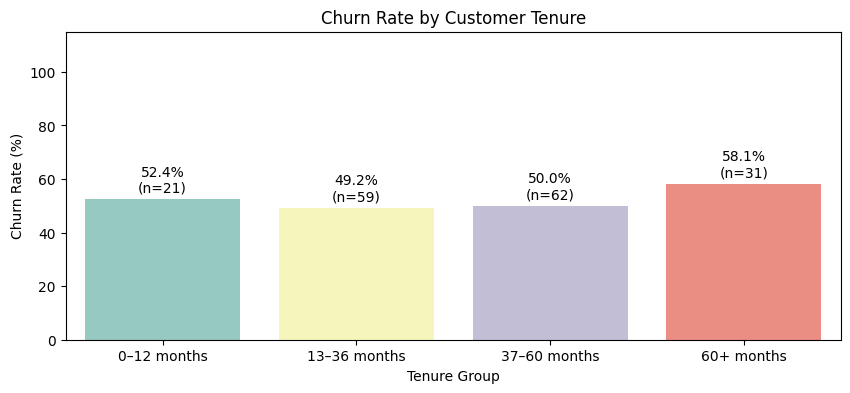

In [40]:
tenure_bins = [0, 12, 36, 60, float("inf")]
tenure_labels = ["0–12 months", "13–36 months", "37–60 months", "60+ months"]

tenure_eda = df.assign(
    Tenure_Group=pd.cut(
        df["Tenure_Months"],
        bins=tenure_bins,
        labels=tenure_labels
    )
)

tenure_summary = tenure_eda.groupby("Tenure_Group", observed=False).agg(
    Customer_Count=("Churn", "size"),
    Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    x=tenure_summary.index,
    y=tenure_summary["Churn_Rate"],
    hue=tenure_summary.index,
    palette="Set3",
    legend=False
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 115)

for bar, count, rate in zip(
    ax.patches,
    tenure_summary["Customer_Count"],
    tenure_summary["Churn_Rate"]
):
    ax.annotate(
        f"{rate:.1f}%\n(n={count})",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.show()

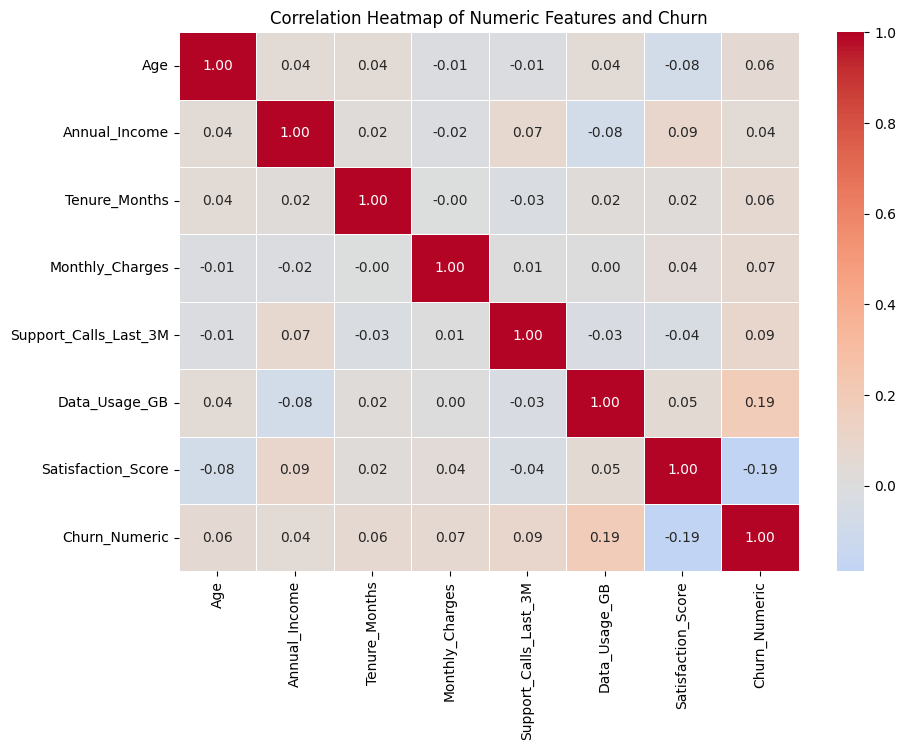

In [41]:
corr_data = df[
    [
        "Age",
        "Annual_Income",
        "Tenure_Months",
        "Monthly_Charges",
        "Support_Calls_Last_3M",
        "Data_Usage_GB",
        "Satisfaction_Score"
    ]
].copy()

# Temporary numeric version only for correlation analysis
corr_data["Churn_Numeric"] = df["Churn"].map({"No": 0, "Yes": 1})

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features and Churn")
plt.show()

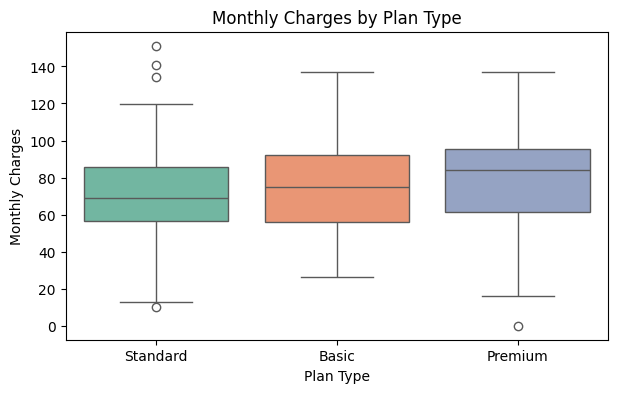

In [42]:
plt.figure(figsize=(7, 4))  #checking charges distribution among plans
sns.boxplot(data=df, x="Plan_Type", y="Monthly_Charges",hue="Plan_Type", palette="Set2")

plt.title("Monthly Charges by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Monthly Charges")
plt.show()

In [43]:
plan_price_summary = df.groupby("Plan_Type")["Monthly_Charges"].agg(
    Customer_Count="count",
    Mean_Charge="mean",
    Median_Charge="median",
    Min_Charge="min",
    Max_Charge="max"
)

print(plan_price_summary.round(2))

           Customer_Count  Mean_Charge  Median_Charge  Min_Charge  Max_Charge
Plan_Type                                                                    
Basic                  44        76.23          74.81       26.23      136.94
Premium                38        79.03          83.88        0.00      137.15
Standard               91        71.91          68.79        9.97      151.18


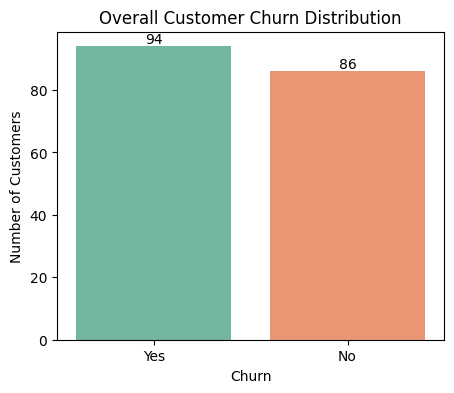

Churn
Yes    52.22
No     47.78
Name: proportion, dtype: float64


In [44]:
plt.figure(figsize=(5, 4))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

print((df["Churn"].value_counts(normalize=True) * 100).round(2))

## EDA Key Findings

- The dataset contains meaningful churn variation across customer groups, so it is suitable for a churn-classification model.
- Customers on **monthly contracts** have the highest churn rate, while **2-year contract** customers have the lowest churn rate. Longer commitments are associated with better retention.
- Churn generally decreases as **satisfaction score** increases. Low-satisfaction customers should be prioritized for retention actions.
- Support-call churn rates vary across groups. Very high rates for 7 or 30 calls are based on very few customers, so they should not be generalized without more data.
- Churn differs across plan types, meaning plan type may provide useful predictive information.
- Customer tenure groups show churn differences and may help the model identify early-risk versus long-term customers.
- The correlation heatmap shows the linear relationships among numerical features and with the churn target. Categorical features were analysed separately using churn-rate charts.

### Business Implication

The retention team should focus especially on customers with monthly contracts, low satisfaction scores, and other risk patterns identified by the model. Since missing a true churner is costly, recall will be an important evaluation metric.

In [51]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\telecombusinessusecase\cleaned_customer_churn.csv")

# Keep only customer behaviour features for clustering
X = df.drop(columns=["Customer_ID", "Churn"])

print("Clustering data shape:", X.shape)
print("\nColumns used for clustering:")
print(X.columns.tolist())

Clustering data shape: (180, 11)

Columns used for clustering:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

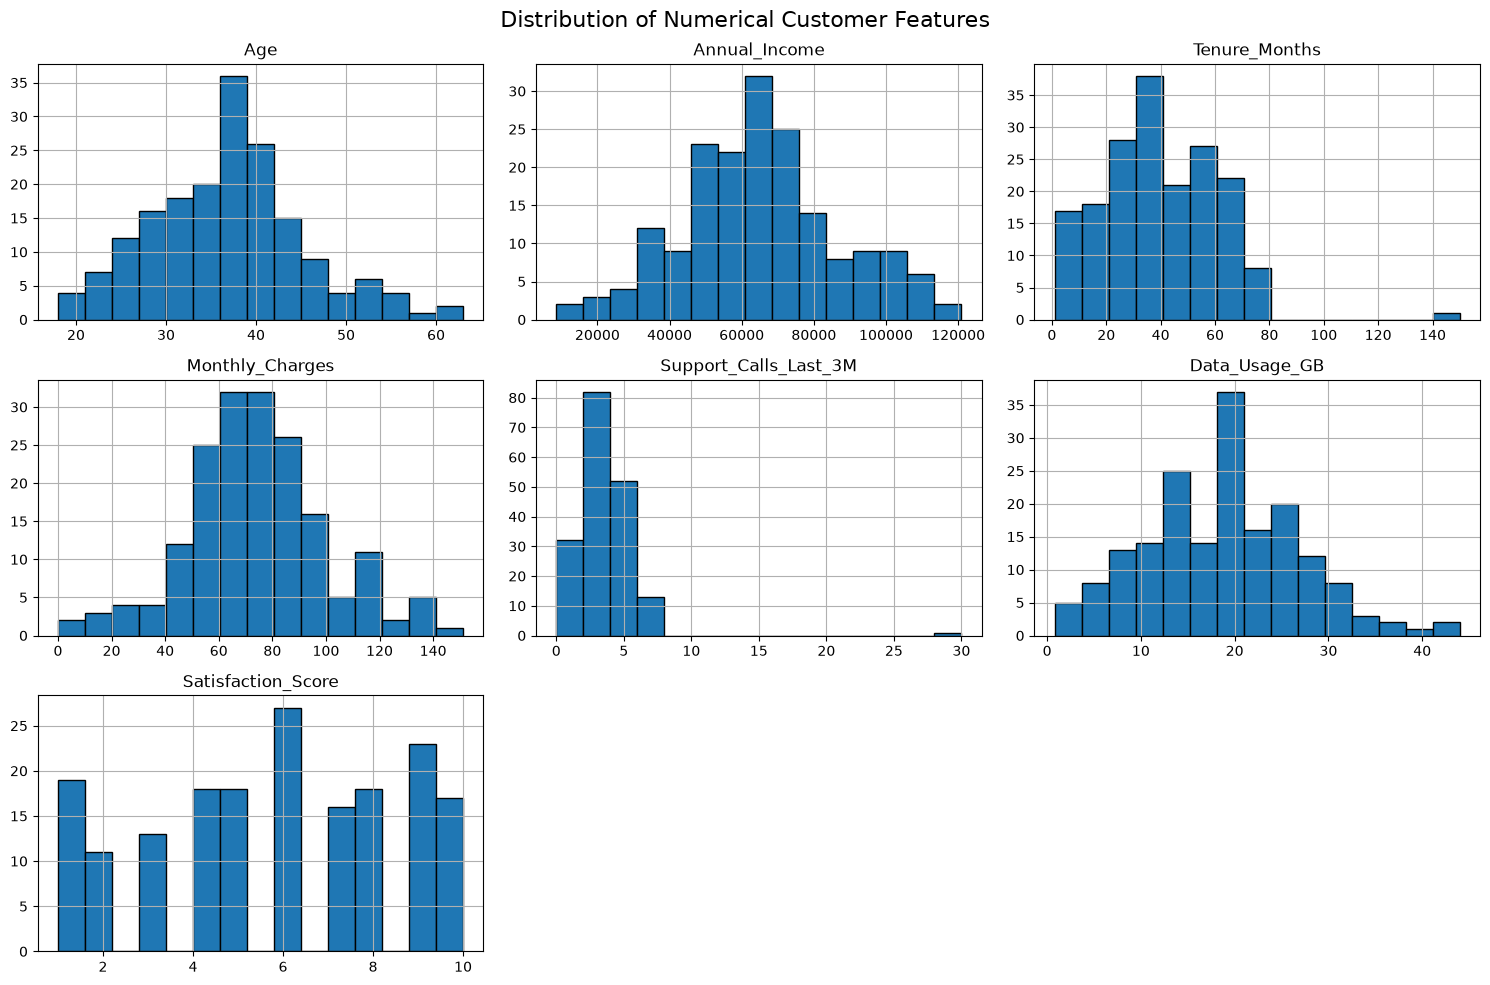

In [53]:
numeric_features = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

df[numeric_features].hist(figsize=(15, 10), bins=15, edgecolor="black")
plt.suptitle("Distribution of Numerical Customer Features", fontsize=16)
plt.tight_layout()
plt.show()

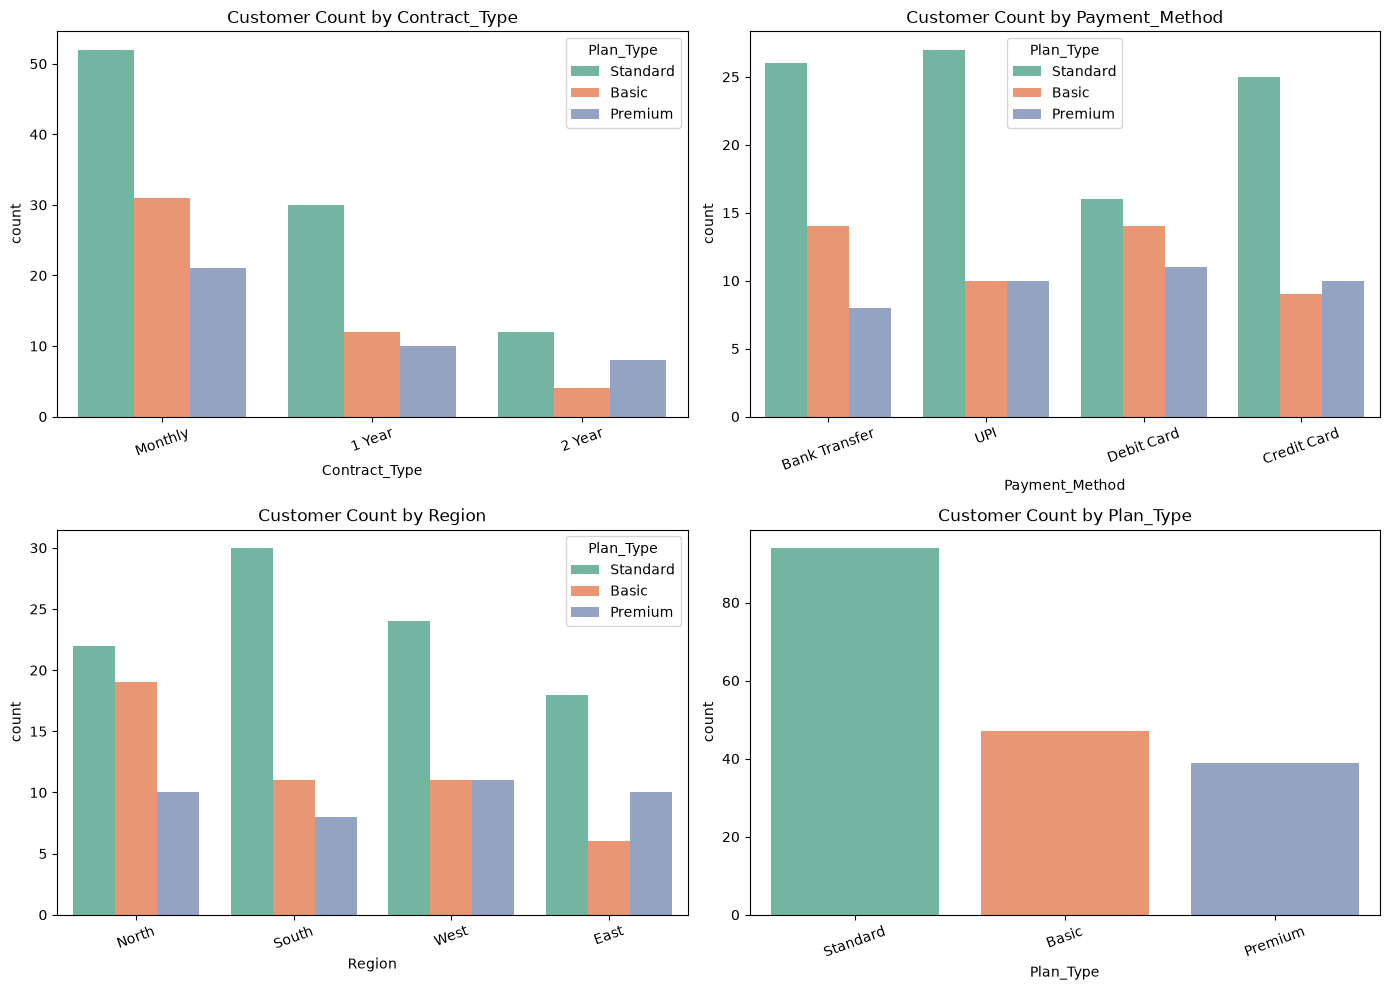

In [62]:
categorical_features = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, column in zip(axes, categorical_features):
    sns.countplot(data=df, x=column, ax=ax, hue="Plan_Type",palette="Set2")
    ax.set_title(f"Customer Count by {column}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

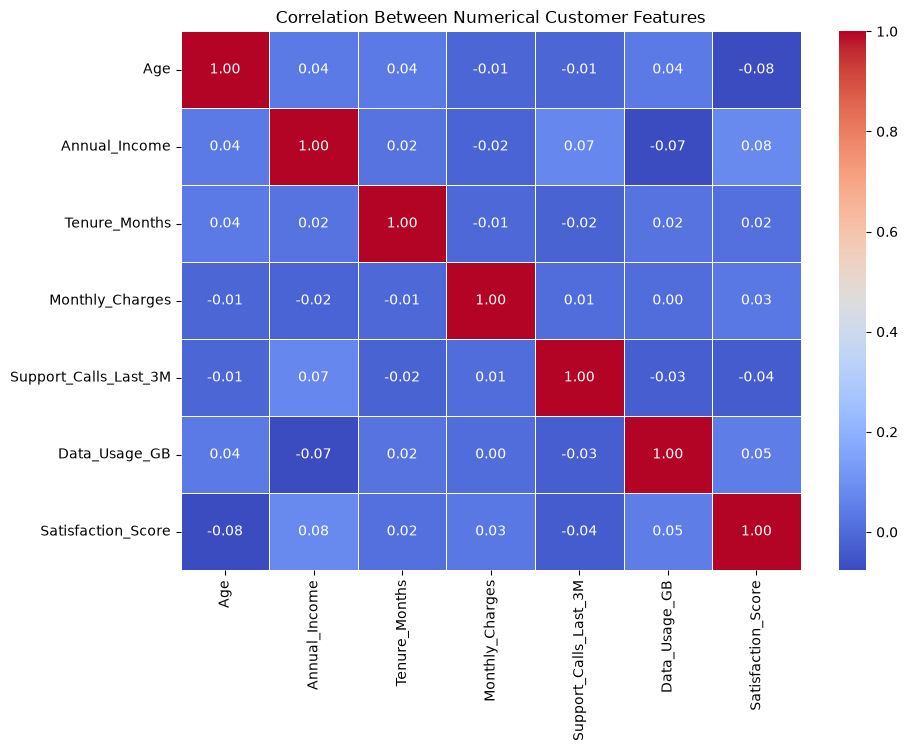

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Customer Features")
plt.show()

In [63]:
numeric_features = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

categorical_features = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Processed data shape:", X_processed.shape)

Processed data shape: (180, 21)


In [64]:
inertias = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_processed)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_processed, cluster_labels)
    )

results = pd.DataFrame({
    "K": list(k_values),
    "Inertia_WCSS": inertias,
    "Silhouette_Score": silhouette_scores
})

results

,K,Inertia_WCSS,Silhouette_Score
0,2,1596.106917,0.080153
1,3,1496.067586,0.070485
2,4,1419.770155,0.077724
3,5,1310.566016,0.073059
4,6,1256.699385,0.074280
5,7,1197.595839,0.074601
6,8,1152.599077,0.068456


WCSS compares each customer with a centroid, while Silhouette compares each customer with other customers in its own and nearby clusters.




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

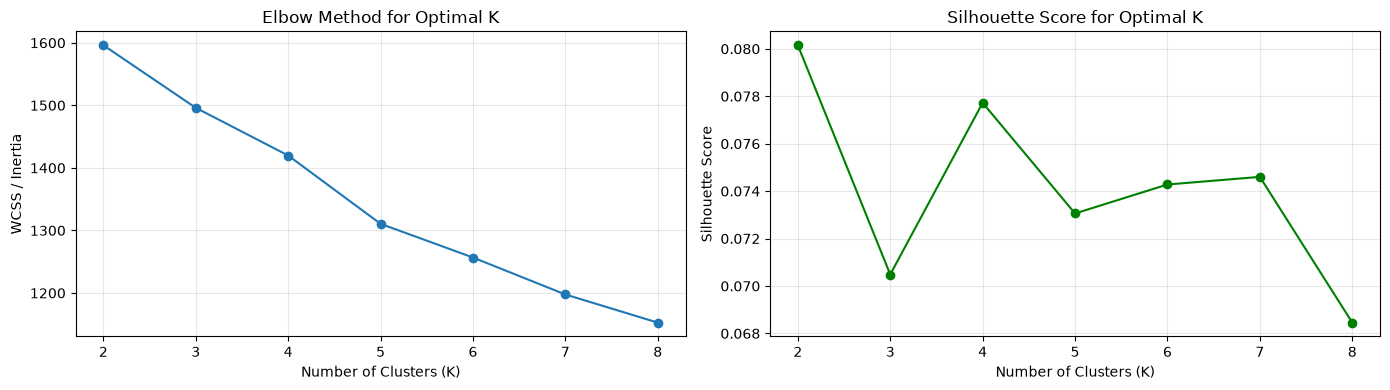

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow curve: WCSS/Inertia
axes[0].plot(results["K"], results["Inertia_WCSS"], marker="o")
axes[0].set_title("Elbow Method for Optimal K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS / Inertia")
axes[0].set_xticks(results["K"])
axes[0].grid(alpha=0.3)

# Silhouette-score curve
axes[1].plot(
    results["K"],
    results["Silhouette_Score"],
    marker="o",
    color="green"
)
axes[1].set_title("Silhouette Score for Optimal K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(results["K"])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Optimal Number of Clusters

We selected **K = 4** customer clusters.

Although K = 2 had the highest silhouette score, it created only two broad customer groups. K = 4 achieved the best silhouette score among the practical multi-cluster options and provides enough distinct segments for targeted telecom business actions.

The Elbow curve also supports selecting a small number of clusters around this range. Therefore, **four customer segments** were chosen for the final analysis.

In [ ]:
# Final K-Means model with K = 4
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Create a results dataset without the original Churn column
df_clustered = df.drop(columns=["Churn"]).copy()

# Assign each customer to one of the four clusters
df_clustered["Cluster"] = final_kmeans.fit_predict(X_processed)

# Number of customers in each cluster
cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers in each cluster:")
print(cluster_counts)

Customers in each cluster:
Cluster
0    42
1    55
2    45
3    38
Name: count, dtype: int64


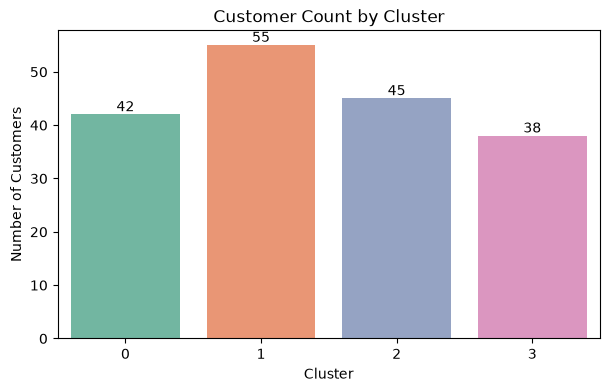

In [ ]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(
    data=df_clustered,
    x="Cluster",
    hue="Cluster",
    palette="Set2",
    legend=False
)

plt.title("Customer Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
numeric_profile = (
    df_clustered
    .groupby("Cluster")[numeric_features]
    .mean()
    .round(2)
)

# Add customer count as the first column
numeric_profile.insert(
    0,
    "Customer_Count",
    df_clustered["Cluster"].value_counts().sort_index()
)

numeric_profile

,Customer_Count,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Cluster,,,,,,,,
0,42,36.81,72497.62,36.64,74.21,2.83,28.08,7.50
1,55,37.96,67827.27,40.29,63.68,2.91,18.79,2.71
2,45,36.71,67200.00,25.93,69.65,4.16,12.62,7.20
3,38,32.89,50789.47,56.76,96.11,2.92,15.18,6.55


In [ ]:
def most_common_with_share(series):
    top_value = series.mode().iloc[0]
    share = (series == top_value).mean() * 100
    return f"{top_value} ({share:.1f}%)"

categorical_profile = (
    df_clustered
    .groupby("Cluster")[categorical_features]
    .agg(most_common_with_share)
)

categorical_profile

,Contract_Type,Payment_Method,Region,Plan_Type
Cluster,,,,
0,Monthly (66.7%),Bank Transfer (33.3%),South (42.9%),Standard (59.5%)
1,Monthly (63.6%),Credit Card (36.4%),West (29.1%),Standard (50.9%)
2,Monthly (44.4%),Bank Transfer (31.1%),North (37.8%),Standard (53.3%)
3,Monthly (55.3%),Debit Card (34.2%),East (28.9%),Standard (44.7%)


In [ ]:
segment_names = {
    0: "Digital Power Users",
    1: "Service Recovery Priority Customers",
    2: "Assisted Onboarding Customers",
    3: "High-Bill Established Customers"
}

df_clustered["Segment"] = df_clustered["Cluster"].map(segment_names)

PCA means Principal Component Analysis.
It is a dimensionality-reduction technique that combines many features into fewer new features called principal components.


PCA_1 captures the largest possible variation in the data, and PCA_2 captures the next-largest variation while being independent of PCA_1.

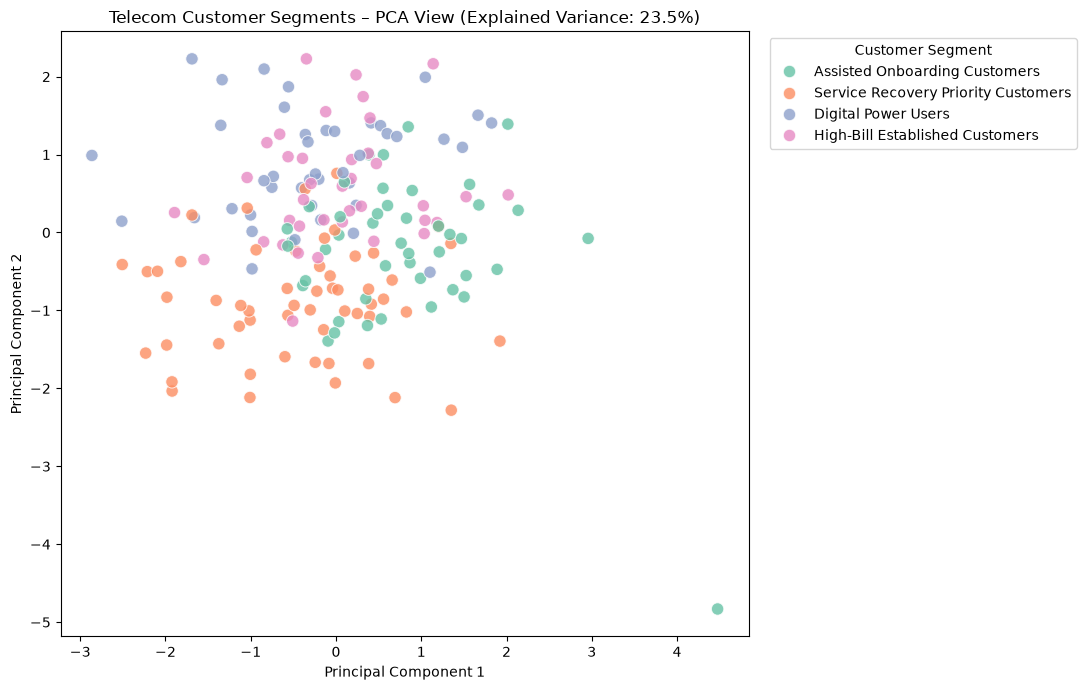

In [ ]:
from sklearn.decomposition import PCA

# Reduce the 21 processed features into two visual components
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_processed)

# Create plotting dataset
pca_df = pd.DataFrame(
    pca_result,
    columns=["PCA_1", "PCA_2"]
)

pca_df["Segment"] = df_clustered["Segment"].values

# Plot the four business segments
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_df,
    x="PCA_1",
    y="PCA_2",
    hue="Segment",
    palette="Set2",
    s=80,
    alpha=0.8
)

variance = pca.explained_variance_ratio_.sum() * 100

plt.title(
    f"Telecom Customer Segments – PCA View "
    f"(Explained Variance: {variance:.1f}%)"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

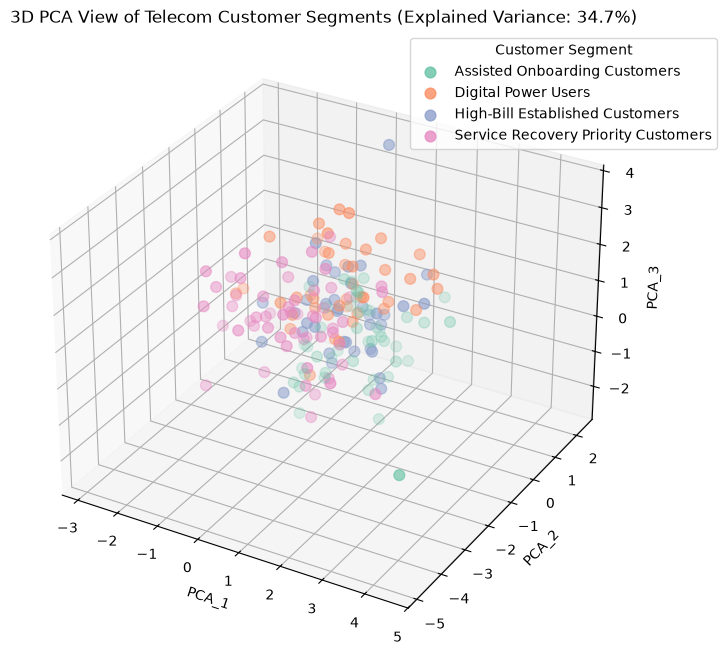

In [ ]:
from sklearn.decomposition import PCA

# Reduce 21 features into 3 principal components
pca_3d = PCA(n_components=3, random_state=42)
pca_3d_result = pca_3d.fit_transform(X_processed)

pca_3d_df = pd.DataFrame(
    pca_3d_result,
    columns=["PCA_1", "PCA_2", "PCA_3"]
)

pca_3d_df["Segment"] = df_clustered["Segment"].values

# Create the 3D graph
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

colors = sns.color_palette("Set2", n_colors=4)

for (segment, group), color in zip(
    pca_3d_df.groupby("Segment"),
    colors
):
    ax.scatter(
        group["PCA_1"],
        group["PCA_2"],
        group["PCA_3"],
        label=segment,
        color=color,
        s=60,
        alpha=0.8
    )

variance_3d = pca_3d.explained_variance_ratio_.sum() * 100

ax.set_title(
    f"3D PCA View of Telecom Customer Segments "
    f"(Explained Variance: {variance_3d:.1f}%)"
)
ax.set_xlabel("PCA_1")
ax.set_ylabel("PCA_2")
ax.set_zlabel("PCA_3")
ax.legend(title="Customer Segment", bbox_to_anchor=(1.15, 1))

plt.show()

### 3D PCA Visualization

The 3D PCA plot represents the four customer segments using three principal components and explains **34.7%** of the total variation in the 21 processed customer features.

This is higher than the 2D PCA view (23.5%), so it provides a richer visual representation of customer behaviour. The segments still show some overlap, reflecting similar behaviours across real telecom customers.

The 3D PCA plot is used only for visualization; the final K-Means model used all 21 processed features to create the four customer segments.

All 21 features together = 100% of customer differences
PCA_1 + PCA_2 graph = 23.5% of those differences
Not shown in the 2D graph = 76.5%

### PCA Cluster Visualization

The PCA plot shows that the four customer segments have distinguishable patterns, although some overlap is present. This is expected in real-world customer data because customers may share similar behaviours across multiple segments.

The first two PCA components explain 23.5% of the total variation. Therefore, the plot is used for visual interpretation, while K-Means created the segments using all 21 processed features.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Hierarchical Clustering with 4 clusters
hierarchical_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_processed)

# Compare silhouette scores at K = 4
kmeans_score = results.loc[
    results["K"] == 4,
    "Silhouette_Score"
].iloc[0]

hierarchical_score = silhouette_score(
    X_processed,
    hierarchical_labels
)

comparison = pd.DataFrame({
    "Model": ["K-Means", "Hierarchical Clustering"],
    "Number_of_Clusters": [4, 4],
    "Silhouette_Score": [kmeans_score, hierarchical_score]
})

comparison

,Model,Number_of_Clusters,Silhouette_Score
0,K-Means,4,0.077724
1,Hierarchical Clustering,4,0.055748


In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
    n_init=10
)

gmm_labels = gmm.fit_predict(X_processed)

gmm_score = silhouette_score(
    X_processed,
    gmm_labels
)

print("GMM Silhouette Score:", round(gmm_score, 4))

GMM Silhouette Score: 0.0206


In [ ]:
%pip install kmodes

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler

# Same 11 clustering features, without ID and Churn
X_kproto = df.drop(columns=["Customer_ID", "Churn"]).copy()

# Scale only numeric columns
scaler = StandardScaler()
X_kproto[numeric_features] = scaler.fit_transform(
    X_kproto[numeric_features]
)

# Find categorical-column positions for K-Prototypes
categorical_indices = [
    X_kproto.columns.get_loc(col)
    for col in categorical_features
]

# Fit K-Prototypes with K = 4
kproto = KPrototypes(
    n_clusters=4,
    init="Cao",
    n_init=10,
    random_state=42
)

kproto_labels = kproto.fit_predict(
    X_kproto.to_numpy(),
    categorical=categorical_indices
)

# Compare on the same processed matrix used for other models
kprototypes_score = silhouette_score(
    X_processed,
    kproto_labels
)

print("K-Prototypes Silhouette Score:", round(kprototypes_score, 4))

K-Prototypes Silhouette Score: 0.0674


In [ ]:
comparison.loc[len(comparison)] = [
    "K-Prototypes",
    4,
    kprototypes_score
]

comparison.sort_values(
    "Silhouette_Score",
    ascending=False
)

,Model,Number_of_Clusters,Silhouette_Score
0,K-Means,4,0.077724
2,K-Prototypes,4,0.067429
1,Hierarchical Clustering,4,0.055748


Business problem
Identify customers with unusual combinations of billing, usage, tenure, support requests, and satisfaction, so the telecom team can investigate possible plan mismatch, unresolved service issues, or abnormal customer behaviour.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

dbscan_features = [
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

X_dbscan = df[dbscan_features].copy()

# DBSCAN is distance-based, so scaling is essential
scaler = StandardScaler()
X_dbscan_scaled = scaler.fit_transform(X_dbscan)

print("DBSCAN data shape:", X_dbscan_scaled.shape)

DBSCAN data shape: (180, 5)


### DBSCAN Parameter Preparation

DBSCAN uses two key parameters:

- **`eps`**: the maximum distance within which customers are considered neighbours.
- **`min_samples`**: the minimum number of nearby customers required to form a dense customer-behaviour group.

We set `min_samples = 10` and created a k-distance graph using each customer’s distance to its 10th-nearest neighbour.

The bend in this graph helps us select an appropriate `eps` value. Customers outside dense neighbourhoods may later be labelled as noise (`-1`), representing unusual customer behaviour.

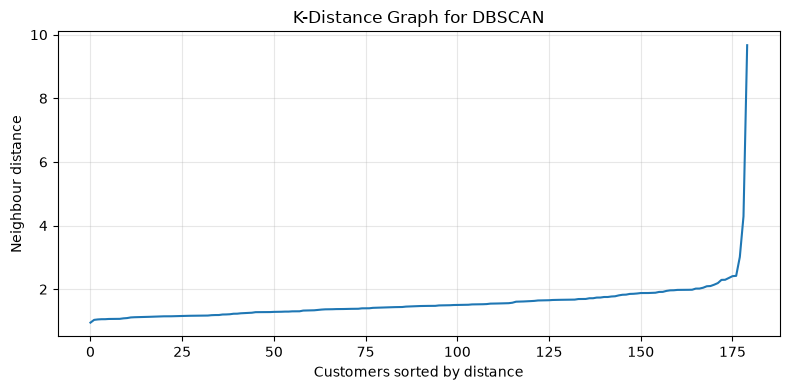

In [ ]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_dbscan_scaled)

distances, indices = neighbors.kneighbors(X_dbscan_scaled)

# Distance to each customer's 10th-nearest neighbour
k_distances = np.sort(distances[:, -1])



plt.figure(figsize=(8, 4))
plt.plot(k_distances)

plt.title("K-Distance Graph for DBSCAN")
plt.xlabel("Customers sorted by distance")
plt.ylabel("Neighbour distance")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

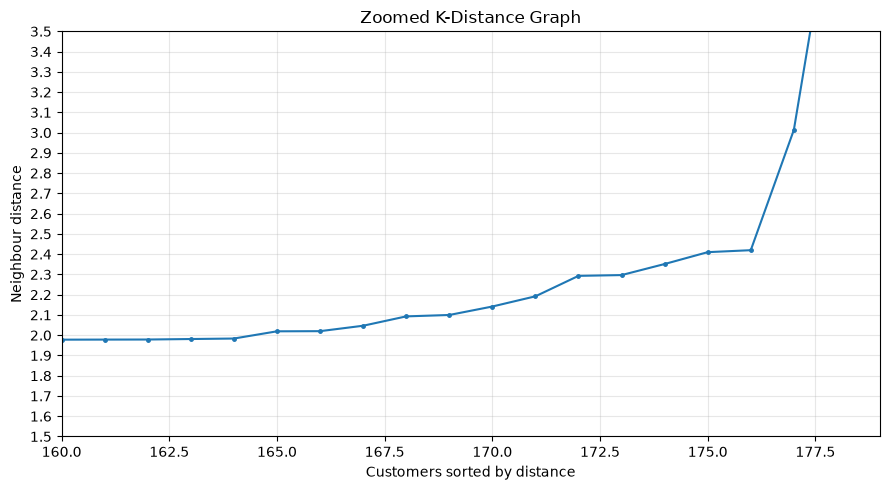

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(k_distances, marker=".", markersize=5)

plt.xlim(len(k_distances) - 20, len(k_distances) - 1)
plt.ylim(1.5, 3.5)
plt.yticks(np.arange(1.5, 3.6, 0.1))

plt.title("Zoomed K-Distance Graph")
plt.xlabel("Customers sorted by distance")
plt.ylabel("Neighbour distance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Core customers:", np.sum(k_distances <= 2.3))

Core customers: 174


In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

eps = 2.3
min_samples = 10

dbscan = DBSCAN(eps=eps, min_samples=min_samples)

dbscan_labels = dbscan.fit_predict(X_dbscan_scaled)

# Keep ID only to identify customers afterwards
df_dbscan_results = df.drop(columns=["Churn"]).copy()

df_dbscan_results["DBSCAN_Label"] = dbscan_labels

df_dbscan_results["Behaviour_Status"] = np.where(
    df_dbscan_results["DBSCAN_Label"] == -1,
    "Unusual Behaviour",
    "Normal Dense Behaviour Group"
)

print(
    "Number of dense clusters:",
    len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
)

print(
    "Number of unusual customers:",
    (dbscan_labels == -1).sum()
)

df_dbscan_results["Behaviour_Status"].value_counts()

Number of dense clusters: 1
Number of unusual customers: 3


Behaviour_Status
Normal Dense Behaviour Group    177
Unusual Behaviour                 3
Name: count, dtype: int64

### Why did DBSCAN group 177 customers when only 174 met the core condition?

With `eps = 2.3` and `min_samples = 10`:

- **174 core customers** have at least 10 customers, including themselves, within distance 2.3.
- **3 border customers** have fewer than 10 nearby customers, but are within distance 2.3 of a core customer, so they also join the cluster.
- **3 noise customers** do not meet the core condition and have no core customer within distance 2.3.

Therefore, **174 core + 3 border = 177 clustered customers**.

The distance limit stays **2.3**. The k-distance graph checks the distance needed to reach 10 customers; border customers only need to be close enough to a core customer.

### DBSCAN Result

Using `eps = 2.3` and `min_samples = 10`, DBSCAN identified one dense group containing 177 customers and flagged 3 customers as unusual behaviour (`-1`).

These unusual customers have behaviour patterns that are not similar enough to the main customer group. They can be reviewed for possible plan mismatch, unusually high support needs, or uncommon usage and billing patterns.

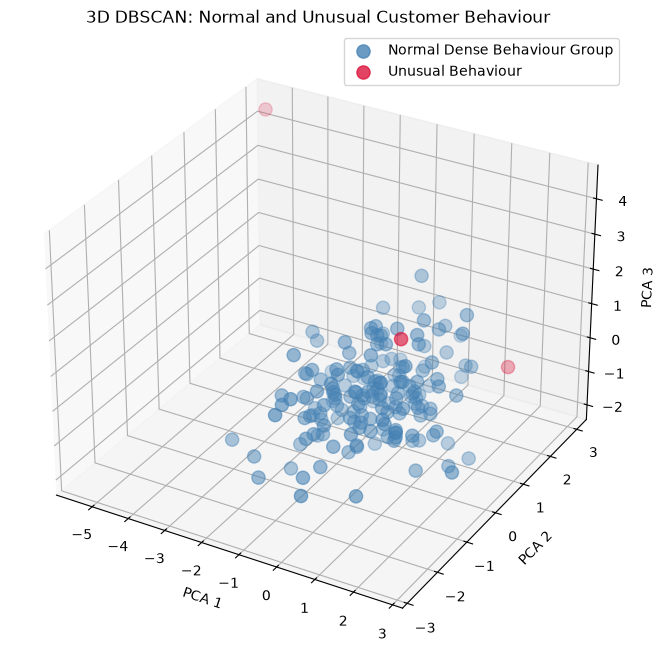

3D PCA explained variance: 61.84 %


In [ ]:
from sklearn.decomposition import PCA


# Reduce the five DBSCAN input features to 3 dimensions for visualization
pca_dbscan_3d = PCA(n_components=3, random_state=42)
dbscan_pca_3d = pca_dbscan_3d.fit_transform(X_dbscan_scaled)

plot_3d = pd.DataFrame(
    dbscan_pca_3d,
    columns=["PCA_1", "PCA_2", "PCA_3"]
)

plot_3d["Behaviour_Status"] = df_dbscan_results["Behaviour_Status"]

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

colors = {
    "Normal Dense Behaviour Group": "steelblue",
    "Unusual Behaviour": "crimson"
}

for status, color in colors.items():
    subset = plot_3d[plot_3d["Behaviour_Status"] == status]

    ax.scatter(
        subset["PCA_1"],
        subset["PCA_2"],
        subset["PCA_3"],
        c=color,
        label=status,
        s=90,
        alpha=0.8
    )

ax.set_title("3D DBSCAN: Normal and Unusual Customer Behaviour")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.legend()

plt.show()

print(
    "3D PCA explained variance:",
    round(pca_dbscan_3d.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

In [ ]:
unusual_customers = df_dbscan_results.loc[
    df_dbscan_results["DBSCAN_Label"] == -1,
    ["Customer_ID"] + dbscan_features
]

display(unusual_customers)

,Customer_ID,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
35,CUST-1030,42.0,80.50,30.0,19.0,3.0
40,CUST-1013,150.0,64.92,3.0,20.8,9.0
55,CUST-1173,51.0,134.89,2.0,44.0,6.0


In [ ]:
from sklearn.ensemble import IsolationForest

isolation_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

isolation_labels = isolation_model.fit_predict(X_dbscan_scaled)

# Keep customer details and DBSCAN results for comparison
df_comparison = df_dbscan_results.copy()

df_comparison["Isolation_Label"] = isolation_labels

# We reverse the score so higher means more unusual
df_comparison["Anomaly_Score"] = (
    -isolation_model.score_samples(X_dbscan_scaled)
)

df_comparison["DBSCAN_Flag"] = (
    df_comparison["DBSCAN_Label"] == -1
)
df_comparison["Isolation_Flag"] = (
    df_comparison["Isolation_Label"] == -1
)

print("DBSCAN flagged:", df_comparison["DBSCAN_Flag"].sum())
print("Isolation Forest flagged:", df_comparison["Isolation_Flag"].sum())



DBSCAN flagged: 3
Isolation Forest flagged: 28


In [ ]:
db_flag = df_comparison["DBSCAN_Flag"]
iso_flag = df_comparison["Isolation_Flag"]

comparison_summary = pd.DataFrame({
    "Result": [
        "Total flagged by DBSCAN",
        "Total flagged by Isolation Forest",
        "Flagged by both models",
        "Flagged only by DBSCAN",
        "Flagged only by Isolation Forest",
        "Not flagged by either model"
    ],
    "Customers": [
        db_flag.sum(),
        iso_flag.sum(),
        (db_flag & iso_flag).sum(),
        (db_flag & ~iso_flag).sum(),
        (iso_flag & ~db_flag).sum(),
        (~db_flag & ~iso_flag).sum()
    ]
})

display(comparison_summary)

,Result,Customers
0,Total flagged by DBSCAN,3
1,Total flagged by Isolation Forest,28
2,Flagged by both models,3
3,Flagged only by DBSCAN,0
4,Flagged only by Isolation Forest,25
5,Not flagged by either model,152


In [59]:
display(
    df_comparison[
        ["Customer_ID"] + dbscan_features
        + ["DBSCAN_Flag", "Isolation_Flag", "Anomaly_Score"]
    ]
    .sort_values("Anomaly_Score", ascending=False)
    .head(10)
)

,Customer_ID,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,DBSCAN_Flag,Isolation_Flag,Anomaly_Score
35,CUST-1030,42.0,80.50,30.0,19.0,3.0,True,True,0.676898
40,CUST-1013,150.0,64.92,3.0,20.8,9.0,True,True,0.629330
55,CUST-1173,51.0,134.89,2.0,44.0,6.0,True,True,0.568234
74,CUST-1094,20.0,27.95,2.0,0.8,1.0,False,True,0.558574
168,CUST-1100,47.0,50.66,2.0,42.7,10.0,False,True,0.552950
43,CUST-1091,43.0,15.86,1.0,6.7,9.0,False,True,0.548777
3,CUST-1112,9.0,85.67,0.0,34.3,9.0,False,True,0.547715
93,CUST-1142,38.0,118.17,7.0,24.0,2.0,False,True,0.536586
89,CUST-1045,53.0,0.00,3.0,29.8,5.0,False,True,0.534177
82,CUST-1119,1.0,98.01,3.0,9.2,1.0,False,True,0.534051


### DBSCAN vs Isolation Forest

- **DBSCAN** flagged 3 customers as unusual.
- **Isolation Forest** flagged 28 customers, including all 3 flagged by DBSCAN.
- Isolation Forest flagged **25 additional customers**, while DBSCAN flagged **0 additional customers**.
- **152 customers** were not flagged by either model.

Both models agree on 3 unusual customers. The additional 25 need further review; flagging more customers does not automatically mean a model is better.

## Hierarchical Customer Segmentation Problem Statement

The telecom business wants to build a **multi-level customer segmentation structure** for progressive targeting.

Management first needs broad customer groups for high-level strategy. Within each broad group, marketing and service teams need smaller customer subgroups for more personalised offers, onboarding, loyalty, and support actions.

Therefore, we use Hierarchical Clustering to create a customer hierarchy and visualise it using a dendrogram. The dendrogram allows the business to view customers at different levels of detail without retraining the model.

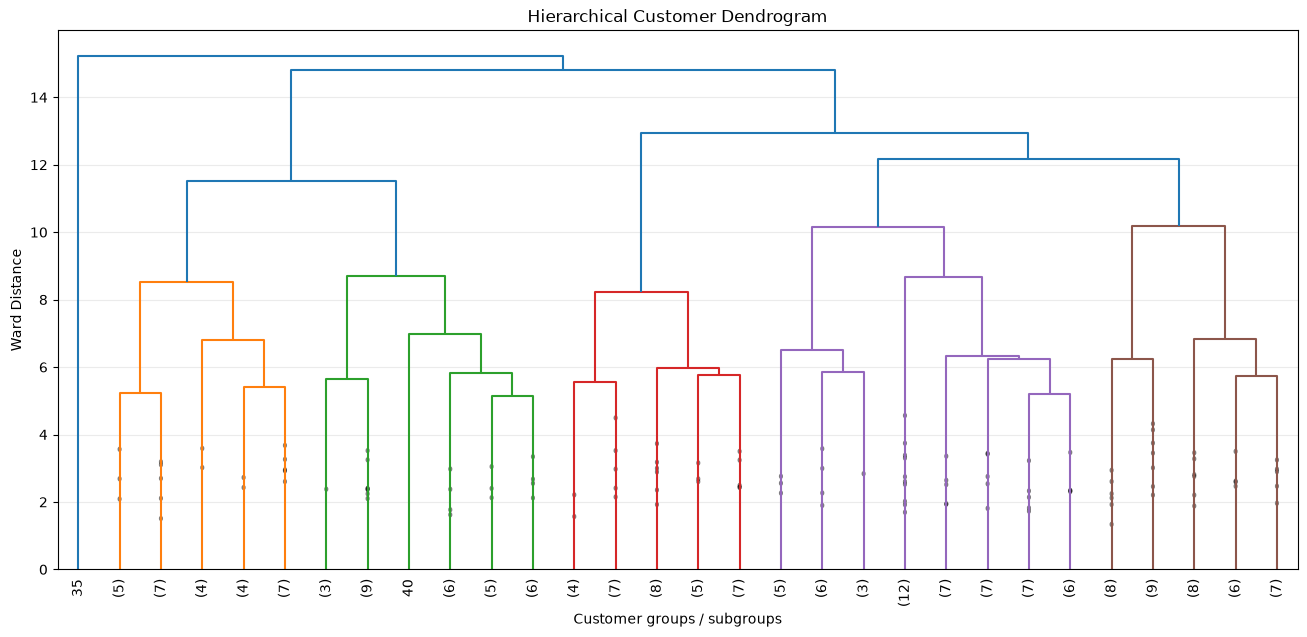

In [90]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Create the hierarchical merge history
hierarchy_linkage = linkage(X_processed, method="ward")

plt.figure(figsize=(16, 7))

dendrogram(
    hierarchy_linkage,
    truncate_mode="lastp",  # keeps the graph readable for 180 customers
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Customer Dendrogram")
plt.xlabel("Customer groups / subgroups")
plt.ylabel("Ward Distance")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [89]:
from sklearn.cluster import AgglomerativeClustering

# A 2-group cut only to identify the isolated top-level branch
top_level_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

top_level_labels = top_level_model.fit_predict(X_processed)

hierarchy_results = df.drop(columns=["Churn"]).copy()
hierarchy_results["Top_Level_Group"] = top_level_labels

group_counts = hierarchy_results["Top_Level_Group"].value_counts()
print(group_counts)

# Find the smallest top-level group
exception_label = group_counts.idxmin()

exception_customer = hierarchy_results.loc[
    hierarchy_results["Top_Level_Group"] == exception_label,
    ["Customer_ID"] + numeric_features
]

display(exception_customer)

Top_Level_Group
0    179
1      1
Name: count, dtype: int64


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
35,CUST-1030,33.0,83900.0,42.0,80.5,30.0,19.0,3.0


In [88]:
# Keep the exceptional customer for support-team review
exception_customer_id = exception_customer["Customer_ID"].iloc[0]

# Core customers for hierarchical segmentation
core_df = df[df["Customer_ID"] != exception_customer_id].copy()

X_core = core_df.drop(columns=["Customer_ID", "Churn"])

# Refit preprocessing only on the core customer population
hierarchical_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X_core_processed = hierarchical_preprocessor.fit_transform(X_core)

print("Core customer dataset shape:", X_core_processed.shape)

Core customer dataset shape: (179, 21)


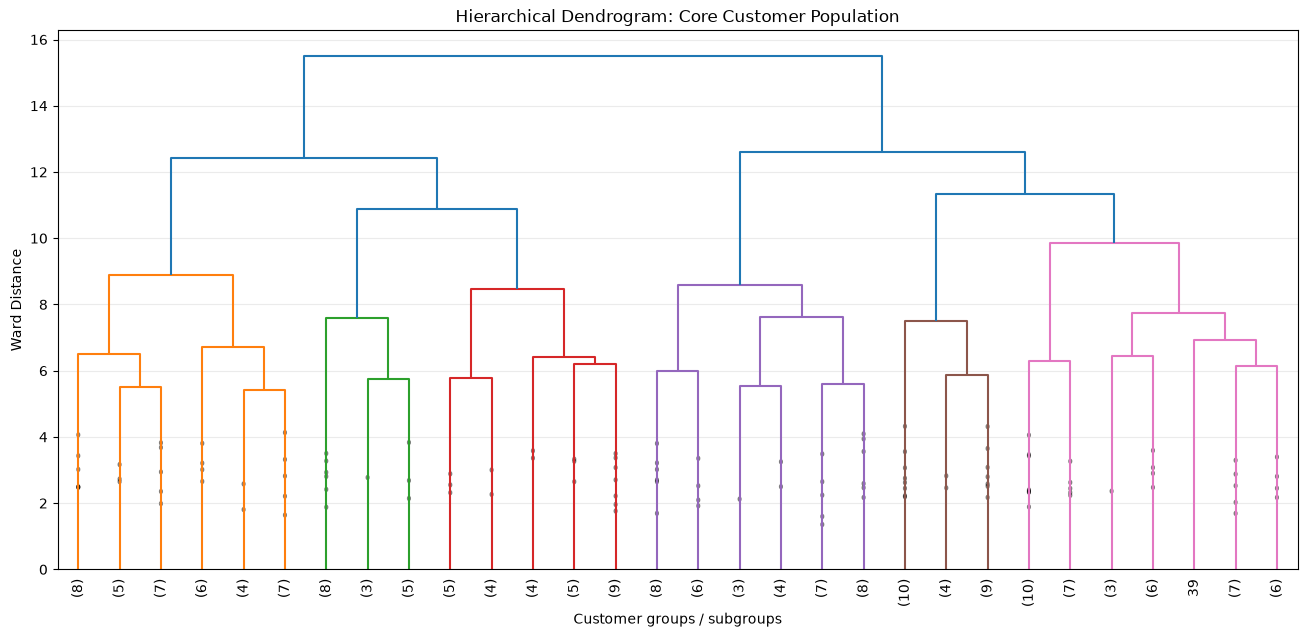

In [87]:
core_linkage = linkage(X_core_processed, method="ward")

plt.figure(figsize=(16, 7))

dendrogram(
    core_linkage,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Dendrogram: Core Customer Population")
plt.xlabel("Customer groups / subgroups")
plt.ylabel("Ward Distance")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [86]:
from scipy.cluster.hierarchy import cut_tree

# Broad, management-level view
parent_labels = cut_tree(
    core_linkage,
    n_clusters=2
).flatten()

# Detailed, team-level view
child_labels = cut_tree(
    core_linkage,
    n_clusters=6
).flatten()

hierarchy_core_results = core_df.drop(columns=["Churn"]).copy()

hierarchy_core_results["Parent_Group"] = parent_labels
hierarchy_core_results["Child_Cluster"] = child_labels

print("Parent group sizes:")
display(hierarchy_core_results["Parent_Group"].value_counts().sort_index())

print("\nChild subgroup sizes:")
display(hierarchy_core_results["Child_Cluster"].value_counts().sort_index())

print("\nChild subgroup inside each parent group:")
display(pd.crosstab(
    hierarchy_core_results["Child_Cluster"],
    hierarchy_core_results["Parent_Group"]
))

Parent group sizes:


Parent_Group
0    99
1    80
Name: count, dtype: int64


Child subgroup sizes:


Child_Cluster
0    23
1    16
2    36
3    40
4    27
5    37
Name: count, dtype: int64


Child subgroup inside each parent group:


Parent_Group,0,1
Child_Cluster,,
0,23,0
1,0,16
2,36,0
3,40,0
4,0,27
5,0,37


In [85]:
# Numerical profile for every detailed child subgroup
child_numeric_profile = (
    hierarchy_core_results
    .groupby(["Parent_Group", "Child_Cluster"])[numeric_features]
    .mean()
    .round(2)
)

display(child_numeric_profile)

Age  Annual_Income  Tenure_Months  \
Parent_Group Child_Cluster                                        
0            0              32.78       53847.83          30.22   
             2              31.22       62033.33          42.53   
             3              40.10       79020.00          48.15   
1            1              41.06       48462.50          42.19   
             4              36.37       83748.15          28.93   
             5              37.35       53416.22          38.62   

                            Monthly_Charges  Support_Calls_Last_3M  \
Parent_Group Child_Cluster                                           
0            0                        70.40                   5.22   
             2                        68.06                   2.00   
             3                        74.04                   3.72   
1            1                        46.53                   3.19   
             4                        69.07                   2.74   
             5                        99.58                   2.19   

                            Data_Usage_GB  Satisfaction_Score  
Parent_Group Child_Cluster                                     
0            0                      17.68                6.00  
             2                      20.61                8.36  
             3                      17.27                7.65  
1            1                      24.02                2.44  
             4                      15.11                2.81  
             5                      19.10                4.70

In [84]:
# Most common category in every detailed child subgroup
child_categorical_profile = (
    hierarchy_core_results
    .groupby(["Parent_Group", "Child_Cluster"])[categorical_features]
    .agg(lambda column: column.mode().iat[0])
)

display(child_categorical_profile)

Contract_Type Payment_Method Region Plan_Type
Parent_Group Child_Cluster                                              
0            0                   Monthly     Debit Card  South  Standard
             2                   Monthly  Bank Transfer  South  Standard
             3                    1 Year     Debit Card  South  Standard
1            1                   Monthly    Credit Card  North     Basic
             4                   Monthly            UPI   West  Standard
             5                   Monthly  Bank Transfer  North     Basic

In [83]:
plan_distribution = (
    pd.crosstab(
        [
            hierarchy_core_results["Parent_Group"],
            hierarchy_core_results["Child_Cluster"]
        ],
        hierarchy_core_results["Plan_Type"],
        normalize="index"
    ) * 100
).round(1)

display(plan_distribution)

Plan_Type                   Basic  Premium  Standard
Parent_Group Child_Cluster                          
0            0               26.1      8.7      65.2
             2               16.7     16.7      66.7
             3               20.0     25.0      55.0
1            1               50.0      6.2      43.8
             4               22.2     29.6      48.1
             5               35.1     32.4      32.4

In [81]:
parent_names = {
    0: "Stable Engagement Customers",
    1: "Experience Improvement Customers"
}

child_names = {
    (0, 0): "Support-Intensive Standard Customers",
    (0, 2): "Highly Satisfied Regular Customers",
    (0, 3): "Established High-Income Customers",
    (1, 1): "Low-Bill High-Usage Dissatisfied Customers",
    (1, 4): "High-Income Low-Engagement Customers",
    (1, 5): "High-Bill Value-Review Customers"
}

hierarchy_core_results["Parent_Segment"] = (
    hierarchy_core_results["Parent_Group"].map(parent_names)
)

hierarchy_core_results["Child_Segment"] = hierarchy_core_results.apply(
    lambda row: child_names[
        (row["Parent_Group"], row["Child_Cluster"])
    ],
    axis=1
)

hierarchy_core_results[
    ["Customer_ID", "Parent_Segment", "Child_Segment"]
].head()

,Customer_ID,Parent_Segment,Child_Segment
0,CUST-1020,Stable Engagement Customers,Support-Intensive Standard Customers
1,CUST-1043,Stable Engagement Customers,Support-Intensive Standard Customers
2,CUST-1157,Experience Improvement Customers,Low-Bill High-Usage Dissatisfied Customers
3,CUST-1112,Stable Engagement Customers,Highly Satisfied Regular Customers
4,CUST-1149,Stable Engagement Customers,Established High-Income Customers


In [98]:
from sklearn.decomposition import PCA

pca_hierarchical_3d = PCA(n_components=3)

hierarchical_coordinates = pca_hierarchical_3d.fit_transform(
    X_core_processed
)

plot_hierarchical_3d = pd.DataFrame(
    hierarchical_coordinates,
    columns=["PCA_1", "PCA_2", "PCA_3"],
    index=hierarchy_core_results.index
)

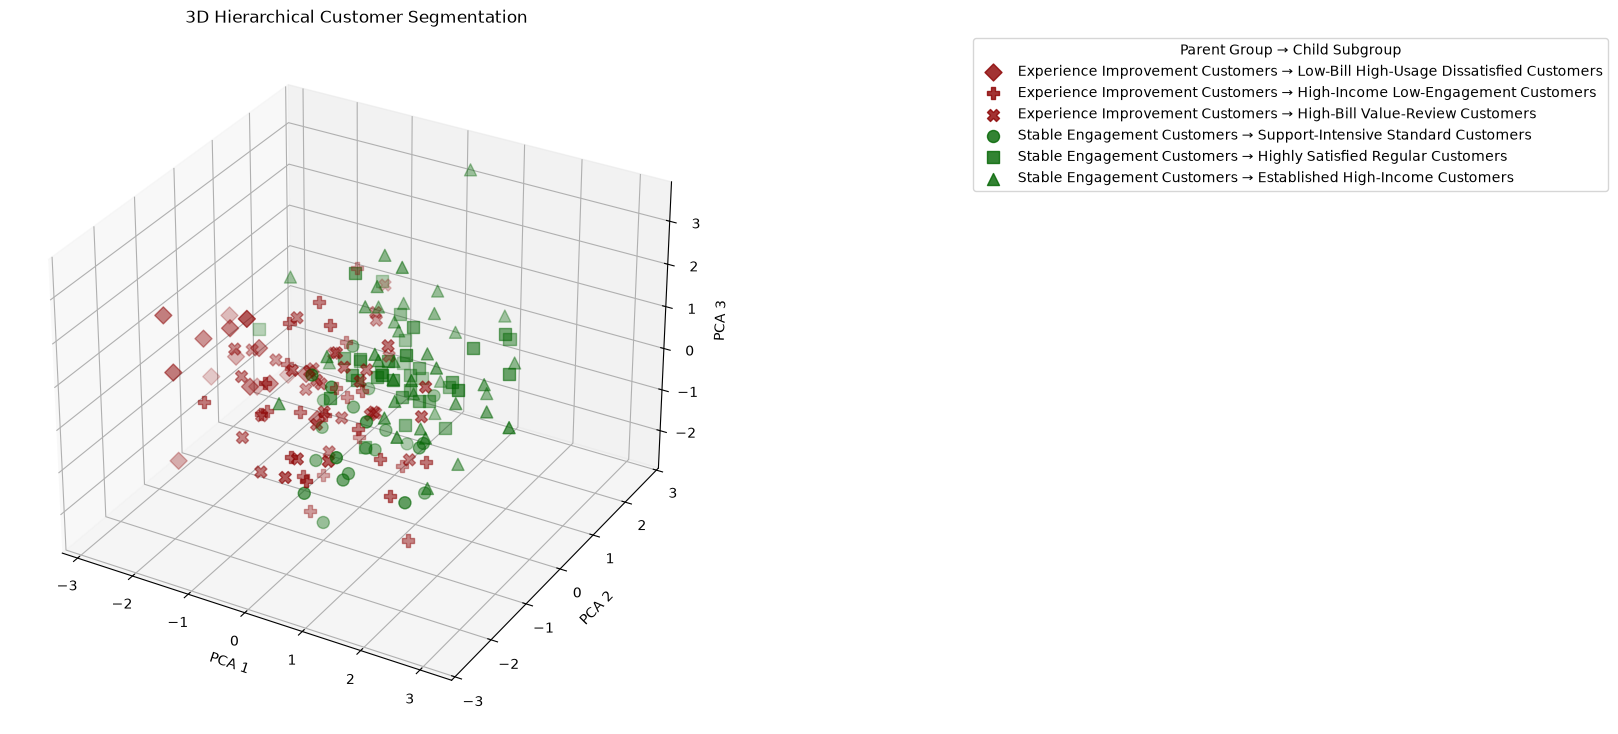

In [99]:
plot_hierarchical_3d["Parent_Segment"] = (
    hierarchy_core_results["Parent_Segment"].values
)

plot_hierarchical_3d["Child_Cluster"] = (
    hierarchy_core_results["Child_Cluster"].values
)

plot_hierarchical_3d["Child_Segment"] = (
    hierarchy_core_results["Child_Segment"].values
)

parent_colors = {
    "Stable Engagement Customers": "darkgreen",
    "Experience Improvement Customers": "darkred"
}

child_markers = {
    0: "o",
    2: "s",
    3: "^",
    1: "D",
    4: "P",
    5: "X"
}

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")

for (parent, child_cluster, child_name), subset in (
    plot_hierarchical_3d
    .groupby(["Parent_Segment", "Child_Cluster", "Child_Segment"])
):
    
    ax.scatter(
        subset["PCA_1"],
        subset["PCA_2"],
        subset["PCA_3"],
        color=parent_colors[parent],
        marker=child_markers[child_cluster],
        s=75,
        alpha=0.8,
        label=f"{parent} → {child_name}"
    )

ax.set_title("3D Hierarchical Customer Segmentation")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

ax.legend(
    title="Parent Group → Child Subgroup",
    bbox_to_anchor=(1.38, 1),
    loc="upper left"
)

plt.show()

## Hierarchical Clustering Conclusion

Hierarchical Clustering was used to create a two-level customer structure for progressive telecom targeting.

One exceptional customer with 30 support calls in three months was identified separately as an escalation case. For the remaining 179 core customers, the dendrogram was cut into:

- **2 parent customer groups** for management-level strategy
- **6 child customer subgroups** for targeted marketing, onboarding, pricing, and service actions

This approach is useful when the business needs to understand not only customer segments, but also how detailed customer subgroups belong to broader customer families.

K-Means remains the better choice for the earlier flat four-segment analysis. Hierarchical Clustering is used here specifically for the parent–child customer hierarchy.

In [100]:
from sklearn.cluster import BisectingKMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import cut_tree

# Six groups from our existing Ward hierarchy
ward_labels = cut_tree(
    core_linkage, n_clusters=6
).flatten()

# Six groups through repeated two-way splits
bisecting_model = BisectingKMeans(
    n_clusters=6,
    n_init=10,
    bisecting_strategy="biggest_inertia",
    random_state=42
)

bisecting_labels = bisecting_model.fit_predict(X_core_processed)

comparison = pd.DataFrame({
    "Model": ["Agglomerative (Ward)", "Bisecting KMeans"],
    "Number of Groups": [6, 6],
    "Silhouette Score": [
        silhouette_score(X_core_processed, ward_labels),
        silhouette_score(X_core_processed, bisecting_labels)
    ]
})

display(comparison.round(4))

,Model,Number of Groups,Silhouette Score
0,Agglomerative (Ward),6,0.0570
1,Bisecting KMeans,6,0.0561


### Hierarchical Clustering Comparison

At six groups, Agglomerative clustering with Ward linkage scored
0.0570, while Bisecting KMeans scored 0.0561.

The difference is very small, and both scores indicate weak cluster
separation. We retained Ward as our working approach with its existing
parent–child interpretation, without claiming a decisive performance advantage.